# Data Assimilation of heat equation on S^2

This notebook demonstrates data assimilation of heat equation on s^2 using DeepONet on a spherical domain.

In [2]:
!pip install healpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 55.7 MB/s eta 0:00:00


## 1. Library Imports
Importing required libraries such as `healpy` for spherical projections, `numpy` for matrix operations, and `scipy.special` for spherical harmonics.

Total pixels on the sphere: 196608


/tmp/ipykernel_1580/2871370127.py:19: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Ylm = sph_harm(m, l, phi_hp, theta_hp)


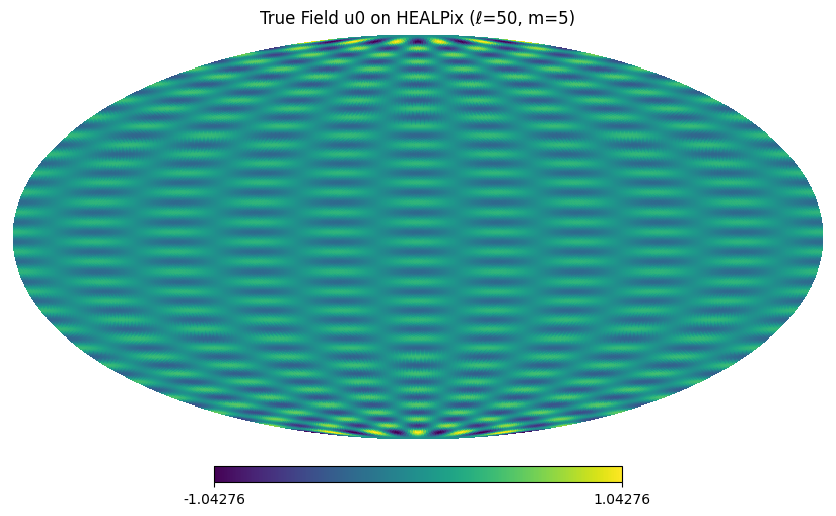

In [3]:
import healpy as hp
import numpy as np
from scipy.special import sph_harm
import matplotlib.pyplot as plt

# 1. Define the grid resolution
NSIDE = 128  # High resolution for l=100
NPIX = hp.nside2npix(NSIDE)
print(f"Total pixels on the sphere: {NPIX}")

# 2. Get the physical coordinates of every pixel
# healpy returns theta (colatitude: 0 to pi) and phi (longitude: 0 to 2pi)
pixel_indices = np.arange(NPIX)
theta_hp, phi_hp = hp.pix2ang(NSIDE, pixel_indices)

# 3. Compute the Analytical Solution (u0)
l, m = 50, 5
# SciPy expects (m, l, phi, theta)
Ylm = sph_harm(m, l, phi_hp, theta_hp)
u0_hp = np.real(Ylm)

# 4. Visualize the Isotropic Map
# Mollweide projection is the standard way to view HEALPix spheres
hp.mollview(u0_hp, title=f"True Field u0 on HEALPix (ℓ={l}, m={m})", cmap="viridis")
plt.show()

# 5. Get Cartesian coordinates (for your TrunkNet!)
x_hp, y_hp, z_hp = hp.pix2vec(NSIDE, pixel_indices)

## 3. HEALPix Graph Laplacian
This section constructs the adjacency matrix for the HEALPix graph, which is required for graph convolutions on the sphere.

In [4]:
import scipy.sparse as sp

def build_healpix_laplacian(nside):
    """
    Builds the normalized adjacency matrix for a HEALPix graph.
    """
    npix = hp.nside2npix(nside)
    # Get the 8 neighbors for every pixel
    neighbors = hp.get_all_neighbours(nside, np.arange(npix))

    row = np.repeat(np.arange(npix), 8)
    col = neighbors.flatten()

    # Remove invalid neighbors (some pixels have 7 neighbors, marked as -1)
    valid = col != -1
    row = row[valid]
    col = col[valid]

    # Create sparse adjacency matrix (A)
    data = np.ones_like(row, dtype=float)
    A = sp.coo_matrix((data, (row, col)), shape=(npix, npix))

    # Add self-loops (A + I) so a pixel remembers its own value
    A = A + sp.eye(npix)

    # Normalize: D^(-1/2) * A * D^(-1/2)
    degree = np.array(A.sum(1)).flatten()
    d_inv_sqrt = np.power(degree, -0.5)
    D_inv_sqrt = sp.diags(d_inv_sqrt)

    L = D_inv_sqrt.dot(A).dot(D_inv_sqrt)
    L = L.tocoo()

    # Convert to PyTorch Sparse Tensor
    indices = torch.tensor(np.vstack((L.row, L.col)), dtype=torch.long)
    values = torch.tensor(L.data, dtype=torch.float32)

    return torch.sparse_coo_tensor(indices, values, torch.Size(L.shape))

## 4. Dataset Generation
Creates custom PyTorch datasets that output `(initial_condition, time, target_state)`.

In [5]:
# -*- coding: utf-8 -*-
"""
Updated DeepONet Heat Equation Script on S^2
"""

import numpy as np
from scipy.special import sph_harm
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F



def get_eval_times(l, target_decays=[0.8, 0.5, 0.1]):
    """
    Calculates the times 't' at which the signal decays to the target percentages.
    Derived from: decay = exp(-l(l+1)t)
    """
    if l == 0:
        return [0.1, 0.2, 0.4] # Fallback

    decay_constant = l * (l + 1)
    # t = -ln(decay) / (l(l+1))
    return [-np.log(d) / decay_constant for d in target_decays]

def generate_grids(n_theta, n_phi):
    t_arr = np.linspace(0, np.pi, n_theta)
    p_arr = np.linspace(0, 2*np.pi, n_phi)
    t_grid, p_grid = np.meshgrid(t_arr, p_arr, indexing="ij")
    return t_arr, p_arr, t_grid, p_grid

# ==========================================
# 1. Grid Generation (Fixed Typo)
# ==========================================
Ntheta = 50
Nphi = 50

# Changed Ntheta_train -> Ntheta and Nphi_train -> Nphi
theta = np.linspace(0, np.pi, Ntheta)
phi = np.linspace(0, 2*np.pi, Nphi)

theta_grid, phi_grid = np.meshgrid(
    theta,
    phi,
    indexing="ij"
)

# ==========================================
# 2. Analytical Solution
# ==========================================
def heat_solution(l, m, theta, phi, t):
    # SciPy expects (m, l, azimuthal/longitude, polar/colatitude)
    Ylm = sph_harm(m, l, phi, theta)
    u = np.real(Ylm)
    return np.exp(-l*(l+1)*t) * u

# ==========================================
# 3. Dataset
# ==========================================
class HeatSphereDataset(Dataset):
    def __init__(self, l, m, theta_grid, phi_grid, times):
        self.theta = theta_grid
        self.phi = phi_grid
        self.times = times
        self.l = l
        self.m = m
        self.u0 = heat_solution(self.l, self.m, self.theta, self.phi, 0)

    def __len__(self):
        return len(self.times)

    def __getitem__(self, idx):
        t = self.times[idx]
        u_t = heat_solution(self.l, self.m, self.theta, self.phi, t)
        return (
            torch.tensor(self.u0, dtype=torch.float32),
            torch.tensor([t], dtype=torch.float32),
            torch.tensor(u_t, dtype=torch.float32)
        )

# ==========================================
# 4. Network Architectures
# ==========================================
class BranchNet(nn.Module):
    def __init__(self, Ntheta, Nphi):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(Ntheta*Nphi, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

    def forward(self, u):
        return self.net(u)

class TrunkNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128), # CHANGED: 3 to 4 to accept (x, y, z, t)
            nn.ReLU(),
            nn.Linear(128, 64)
        )

    def forward(self, x):
        return self.net(x)

class TrunkNetFourier(nn.Module):
    def __init__(self, input_dim=4, num_frequencies=256, sigma=10.0):
        super().__init__()

        # 1. The B Matrix: Randomly sampled frequencies
        # We set requires_grad=False because these are fixed mapping features, not learned weights.
        self.B = nn.Parameter(torch.randn(num_frequencies, input_dim) * sigma, requires_grad=False)

        # 2. The MLP: Input size is now 2 * num_frequencies (because of sin and cos)
        self.net = nn.Sequential(
            nn.Linear(2 * num_frequencies, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

    def forward(self, x):
        # x shape: (batch_size, input_dim) -> (batch_size, 4)

        # Project inputs onto the random frequencies
        # projection shape: (batch_size, num_frequencies)
        projection = 2 * np.pi * torch.matmul(x, self.B.T)

        # Concatenate cosine and sine of the projections
        # Output shape: (batch_size, 2 * num_frequencies)
        fourier_features = torch.cat([torch.cos(projection), torch.sin(projection)], dim=-1)

        # Pass the high-frequency features through the standard MLP
        return self.net(fourier_features)

class PseudoSphericalBranchNet(nn.Module):
    def __init__(self, Ntheta, Nphi):
        super().__init__()
        self.Ntheta = Ntheta
        self.Nphi = Nphi

        # Convolutional Feature Extractor
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=0)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Adaptive pooling ensures the flattened size is always the same (32 * 4 * 4 = 512)
        # regardless of whether you use a 50x50 or 100x100 grid.
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        # Latent feature mapping to match Trunk output
        self.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

    def spherical_pad(self, x):
        # x shape: (batch, channels, height, width) -> (batch, 1, Ntheta, Nphi)
        # Pad width (phi/longitude) circularly: wraps around 2*pi
        x = F.pad(x, pad=(1, 1, 0, 0), mode='circular')
        # Pad height (theta/latitude) by replicating the pole values
        x = F.pad(x, pad=(0, 0, 1, 1), mode='replicate')
        return x

    def forward(self, u):
        # 1. Reshape the flat input back into a 2D grid image
        # u shape coming in: (batch_size, Ntheta * Nphi)
        x = u.view(-1, 1, self.Ntheta, self.Nphi)

        # 2. Apply convolutions with custom spherical padding
        x = self.spherical_pad(x)
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = self.spherical_pad(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        # 3. Standardize size and flatten
        x = self.adaptive_pool(x)
        x = torch.flatten(x, start_dim=1)

        # 4. Map to DeepONet latent space
        return self.fc(x)
class HealpixGCNLayer(nn.Module):
    def __init__(self, in_features, out_features, laplacian):
        super().__init__()
        # The sparse matrix mapping the connections
        self.laplacian = laplacian
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        self.bias = nn.Parameter(torch.FloatTensor(out_features))

        # Standard Xavier initialization
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, x):
        # x shape: (batch_size, npix, in_features)
        batch_size, npix, in_features = x.shape

        # Reshape to multiply with the sparse (npix, npix) Laplacian
        x_reshaped = x.permute(1, 0, 2).reshape(npix, -1)

        # Pass messages between neighboring pixels!
        support = torch.sparse.mm(self.laplacian, x_reshaped)

        # Reshape back and apply weights
        support = support.reshape(npix, batch_size, in_features).permute(1, 0, 2)
        return torch.matmul(support, self.weight) + self.bias

class HealpixBranchNet(nn.Module):
    def __init__(self, nside, laplacian):
        super().__init__()
        self.nside = nside
        self.npix = hp.nside2npix(nside)

        # Graph Convolutions
        self.gc1 = HealpixGCNLayer(1, 16, laplacian)
        self.gc2 = HealpixGCNLayer(16, 32, laplacian)

        # Map the 32 features to the DeepONet latent space
        self.fc = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

    def forward(self, u0_hp):
        # u0_hp is a 1D array of HEALPix pixels -> shape: (batch_size, npix)
        x = u0_hp.unsqueeze(-1) # -> (batch_size, npix, 1 feature)

        x = torch.relu(self.gc1(x))
        x = torch.relu(self.gc2(x))

        # Global Average Pooling: Average the features across all 196,608 pixels
        # x shape becomes (batch_size, 32)
        x = torch.mean(x, dim=1)

        return self.fc(x)


class HealpixHeatDataset(Dataset):
    def __init__(self, l, m, nside, times):
        self.l = l
        self.m = m
        self.nside = nside
        self.npix = hp.nside2npix(nside)
        self.times = times

        # 1. Precompute pixel coordinates
        self.pixel_indices = np.arange(self.npix)
        self.theta_hp, self.phi_hp = hp.pix2ang(self.nside, self.pixel_indices)

        # 2. Precompute Cartesian coordinates for the TrunkNet
        self.x_hp, self.y_hp, self.z_hp = hp.pix2vec(self.nside, self.pixel_indices)

        # 3. Calculate u0 (Initial state at t=0)
        Ylm = sph_harm(self.m, self.l, self.phi_hp, self.theta_hp)
        self.u0 = np.real(Ylm)

    def __len__(self):
        return len(self.times)

    def __getitem__(self, idx):
        t = self.times[idx]

        # True field at time t (exponential decay)
        decay = np.exp(-self.l * (self.l + 1) * t)
        u_t = decay * self.u0

        return (
            torch.tensor(self.u0, dtype=torch.float32),
            torch.tensor([t], dtype=torch.float32),
            torch.tensor(u_t, dtype=torch.float32)
        )

class SineLayer(nn.Module):
    """
    A custom linear layer with a Sine activation and specific weight initialization.
    """
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                # First layer initialization bounds
                self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)
            else:
                # Hidden layer initialization bounds
                bound = np.sqrt(6 / self.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


class SirenTrunkNet(nn.Module):
    """
    The full SIREN Trunk Network.
    """
    def __init__(self, in_features=4, hidden_features=128, out_features=64, omega_0=30.0):
        super().__init__()

        # 1. First layer (maps the 4D coordinates to hidden space)
        self.layer1 = SineLayer(in_features, hidden_features, is_first=True, omega_0=omega_0)

        # 2. Hidden layer
        self.layer2 = SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0)

        # 3. Final linear projection (no sine activation on the very last output
        # to match the unconstrained latent space of the Branch)
        self.final_linear = nn.Linear(hidden_features, out_features)

        with torch.no_grad():
            bound = np.sqrt(6 / hidden_features) / omega_0
            self.final_linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        return self.final_linear(x)

class DeepONet(nn.Module):
    def __init__(self, branch, trunk):
        super().__init__()
        self.branch = branch
        self.trunk = trunk

    def forward(self, u, coords):
        b = self.branch(u)
        t = self.trunk(coords)
        return torch.sum(b*t, dim=-1)


def fibonacci_sphere(samples=5000):
    """
    Generates a low-discrepancy Fibonacci lattice on S^2.
    Returns Cartesian (x,y,z) and spherical (theta, phi) coordinates.
    """
    golden_angle = np.pi * (3.0 - np.sqrt(5.0))
    indices = np.arange(samples)

    # z goes from 1 to -1 (Vertical axis matches cos(theta))
    z = 1.0 - (indices / float(samples - 1)) * 2.0
    theta = np.arccos(z)  # Polar angle [0, pi]

    phi = (golden_angle * indices) % (2 * np.pi)  # Azimuthal angle [0, 2pi]

    radius = np.sin(theta)
    x = radius * np.cos(phi)
    y = radius * np.sin(phi)

    return x, y, z, theta, phi

# Add this before calling train_model()
# total_train_tuples = len(times) * Ntheta * Nphi
# print(f"Total (theta, phi, t) tuples sampled for training: {total_train_tuples}")

# # Add this before your evaluation/plotting loop
# total_test_tuples = len(times) * Ntheta_test * Nphi_test
# print(f"Total (theta, phi, t) tuples sampled for testing: {total_test_tuples}")

# ==========================================
# 5. Initialization & Training Loop
# ==========================================

NSIDE = 128
print("Building Graph Laplacian (this takes a few seconds)...")
laplacian = build_healpix_laplacian(NSIDE)

# Use the new Graph Convolutional Branch
branch = HealpixBranchNet(NSIDE, laplacian)

# Keep the SIREN trunk!
trunk = SirenTrunkNet(in_features=4, hidden_features=128, out_features=64, omega_0=50.0)

model = DeepONet(branch, trunk)
# # branch = BranchNet(Ntheta, Nphi)
# branch = PseudoSphericalBranchNet(Ntheta, Nphi)
# trunk = TrunkNet()
# # trunk = TrunkNetFourier(input_dim=4, num_frequencies=256, sigma=200.0)
# model = DeepONet(branch, trunk)

# optimizer = optim.Adam(model.parameters(), lr=1e-3)
# loss_fn = nn.MSELoss()

def train_model(dataset, num_epochs=200):
    for epoch in range(num_epochs):
        total_loss = 0
        for u0, t, u_true in dataset:
            u0 = u0.unsqueeze(0)
            u_true = u_true.flatten()

            coords = []
            for i in range(Ntheta):
                for j in range(Nphi):
                    th = theta_grid[i,j]
                    ph = phi_grid[i,j]

                    # CHANGED: Cartesian Embedding
                    x = np.sin(th) * np.cos(ph)
                    y = np.sin(th) * np.sin(ph)
                    z = np.cos(th)

                    coords.append([x, y, z, t.item()])

            coords = torch.tensor(coords, dtype=torch.float32)

            pred = model(u0, coords)
            loss = loss_fn(pred, u_true)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss}")


def train_model_healpix(dataset, model, optimizer, loss_fn, num_epochs=1000, n_samples=5000):
    for epoch in range(num_epochs):
        total_loss = 0

        for u0, t, u_true in dataset:
            # Add batch dimension for the BranchNet: shape (1, npix)
            u0 = u0.unsqueeze(0)

            # Randomly sample 'n_samples' pixels to evaluate for this specific batch
            idx = np.random.choice(dataset.npix, n_samples, replace=False)

            # Get the (x, y, z) coordinates for the sampled pixels
            x = dataset.x_hp[idx]
            y = dataset.y_hp[idx]
            z = dataset.z_hp[idx]

            # Create the (x, y, z, t) tuple tensor for the TrunkNet
            t_arr = np.full((n_samples,), t.item())
            coords = np.stack([x, y, z, t_arr], axis=1)
            coords = torch.tensor(coords, dtype=torch.float32)

            # Get the ground truth values for ONLY the sampled pixels
            u_true_sampled = u_true[idx]

            # Forward Pass
            pred = model(u0, coords)
            loss = loss_fn(pred, u_true_sampled)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss}")

def train_model_fibonacci(dataset, model, optimizer, loss_fn, num_epochs=1000, n_samples=5000):
    # Generate the quasi-Monte Carlo point set once per run
    x, y, z, theta, phi = fibonacci_sphere(n_samples)

    for epoch in range(num_epochs):
        total_loss = 0

        for u0, t, _ in dataset:
            # Add batch dimension for the BranchNet: shape (1, npix)
            u0 = u0.unsqueeze(0)

            # Create the (x, y, z, t) tuple tensor for the TrunkNet
            t_arr = np.full((n_samples,), t.item())
            coords = np.stack([x, y, z, t_arr], axis=1)
            coords = torch.tensor(coords, dtype=torch.float32)

            # Calculate EXACT ground truth for the Fibonacci points
            # using the analytical heat equation solution
            decay = np.exp(-dataset.l * (dataset.l + 1) * t.item())
            Ylm = sph_harm(dataset.m, dataset.l, phi, theta)
            u_true_sampled = torch.tensor(decay * np.real(Ylm), dtype=torch.float32)

            # Forward Pass
            pred = model(u0, coords)

            # Squeeze pred to ensure shape matches u_true_sampled (n_samples,)
            loss = loss_fn(pred.squeeze(), u_true_sampled)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss}")

# Train the model
times = [0.1, 0.2, 0.4]
experiments = [(2,1), (3,1), (4,2)]

# for l, m in experiments:
#     print(f"\nTraining for (l,m) = ({l},{m})")
#     dataset = HeatSphereDataset(l, m, theta_grid, phi_grid, times)
#     train_model(dataset)




Building Graph Laplacian (this takes a few seconds)...


## 7. Plotting and Evaluation
Visualization functions to compare DeepONet predictions against the analytical truth.

In [6]:
def predict_healpix_field(model, dataset, t):
    """Evaluates the full HEALPix sphere at a given time step."""
    model.eval()
    with torch.no_grad():
        u0_tensor = torch.tensor(dataset.u0, dtype=torch.float32).unsqueeze(0)

        # Build coordinates for all pixels
        t_arr = np.full((dataset.npix,), t)
        coords = np.stack([dataset.x_hp, dataset.y_hp, dataset.z_hp, t_arr], axis=1)
        coords = torch.tensor(coords, dtype=torch.float32)

        # Predict the whole map at once
        pred = model(u0_tensor, coords)

    model.train() # Set back to train mode
    return pred.numpy()

def plot_healpix_comparison(dataset, model, t):
    # Get True Field
    decay = np.exp(-dataset.l * (dataset.l + 1) * t)
    true_field = decay * dataset.u0

    # Get Predicted Field
    pred_field = predict_healpix_field(model, dataset, t)

    # Sync colorbars so they share the same min/max bounds
    vmin = min(true_field.min(), pred_field.min())
    vmax = max(true_field.max(), pred_field.max())

    plt.figure(figsize=(12, 5))

    hp.mollview(true_field, sub=(1, 2, 1), title=f"True Field t={t:.4f}", min=vmin, max=vmax, cmap="viridis")
    hp.mollview(pred_field, sub=(1, 2, 2), title=f"Predicted Field t={t:.4f}", min=vmin, max=vmax, cmap="viridis")

    plt.suptitle(f"HEALPix DeepONet on S² (ℓ={dataset.l}, m={dataset.m})")
    plt.show()

## 6. Training Functions
Defines training loops for different experiments (standard grid, data assimilation, fibonacci sphere).

In [7]:
def train_and_track_da(dataset, model, optimizer, loss_fn, num_epochs=1000, n_samples=5000):
    train_losses, test_losses = [], []

    for epoch in range(num_epochs):
        epoch_train_loss, epoch_test_loss = 0, 0

        for u0, t, u_true in dataset:
            u0 = u0.unsqueeze(0)

            # --- TRAINING STEP ---
            model.train()
            optimizer.zero_grad()

            idx = np.random.choice(dataset.npix, n_samples, replace=False)
            t_arr_train = np.full((n_samples,), t.item())
            coords_train = torch.tensor(np.stack([dataset.x_hp[idx], dataset.y_hp[idx], dataset.z_hp[idx], t_arr_train], axis=1), dtype=torch.float32)
            u_true_sampled = u_true[idx]

            pred_train = model(u0, coords_train)
            loss_train = loss_fn(pred_train.squeeze(), u_true_sampled)
            loss_train.backward()
            optimizer.step()

            epoch_train_loss += loss_train.item()

            # --- TESTING STEP ---
            model.eval()
            with torch.no_grad():
                t_arr_test = np.full((dataset.npix,), t.item())
                coords_test = torch.tensor(np.stack([dataset.x_hp, dataset.y_hp, dataset.z_hp, t_arr_test], axis=1), dtype=torch.float32)
                pred_test = model(u0, coords_test)
                loss_test = loss_fn(pred_test.squeeze(), u_true)
                epoch_test_loss += loss_test.item()

        train_losses.append(epoch_train_loss / len(dataset))
        test_losses.append(epoch_test_loss / len(dataset))

        if epoch % 50 == 0:
            print(f"Epoch {epoch:04d} | Train: {train_losses[-1]:.2e} | Test: {test_losses[-1]:.2e}")

    return train_losses, test_losses

## 7. Plotting and Evaluation
Visualization functions to compare DeepONet predictions against the analytical truth.

In [8]:
def plot_da_heatmap_grid(dataset, model, times_to_plot):
    num_rows = len(times_to_plot)
    plt.figure(figsize=(15, 4 * num_rows))

    for row_idx, t in enumerate(times_to_plot):
        # True Field
        decay = np.exp(-dataset.l * (dataset.l + 1) * t)
        u_true = decay * dataset.u0

        # Predicted Field
        pred_field = predict_healpix_field(model, dataset, t)
        error = np.abs(u_true - pred_field)

        vmin = min(u_true.min(), pred_field.min())
        vmax = max(u_true.max(), pred_field.max())

        idx_true = (row_idx * 3) + 1
        idx_pred = (row_idx * 3) + 2
        idx_err  = (row_idx * 3) + 3

        hp.mollview(u_true, sub=(num_rows, 3, idx_true), title=f"True Field t={t:.3f}", min=vmin, max=vmax, cmap="viridis", cbar=False)
        hp.mollview(pred_field, sub=(num_rows, 3, idx_pred), title=f"Predicted Field t={t:.3f}", min=vmin, max=vmax, cmap="viridis", cbar=False)
        hp.mollview(error, sub=(num_rows, 3, idx_err), title=f"Error (Max: {error.max():.2e})", cmap="plasma", cbar=True)

    plt.suptitle(f"Data Assimilation Rollout (ℓ={dataset.l}, m={dataset.m})", fontsize=16)
    plt.show()

In [ ]:
def plot_loss_curves(train_losses, test_losses, l, m, title_prefix=""):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss (5k points)", color='blue', alpha=0.8)
    plt.plot(test_losses, label="Test Loss (196k points)", color='orange', alpha=0.8)

    plt.yscale('log')
    plt.xlabel("Epochs")
    plt.ylabel("Mean Squared Error (Log Scale)")
    plt.title(f"{title_prefix} Loss Convergence (ℓ={l}, m={m})")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [7]:


# # Replace your `experiments` loop with this:

# # 1. Train exclusively on (3,1) so the network doesn't overwrite its weights
# l_target, m_target = 3, 1
# print(f"\nTraining for (l,m) = ({l_target},{m_target})")

# dataset = HeatSphereDataset(l_target, m_target, theta_grid, phi_grid, times)

# # 2. Increase epochs! DeepONets need time to map operators.
# train_model(dataset, num_epochs=1000)







# # ==========================================
# # 6. Testing & Evaluation
# # ==========================================
# Ntheta_test = 100
# Nphi_test = 100

# theta_test = np.linspace(0, np.pi, Ntheta_test)
# phi_test = np.linspace(0, 2*np.pi, Nphi_test)

# theta_test_grid, phi_test_grid = np.meshgrid(
#     theta_test,
#     phi_test,
#     indexing="ij"
# )

# def true_field(l, m, t):
#     return heat_solution(l, m, theta_test_grid, phi_test_grid, t)

# def predict_field(model, u0, t):
#     coords = []
#     for i in range(len(theta_test)):
#         for j in range(len(phi_test)):
#             th = theta_test[i]
#             ph = phi_test[j]

#             # CHANGED: Cartesian Embedding
#             x = np.sin(th) * np.cos(ph)
#             y = np.sin(th) * np.sin(ph)
#             z = np.cos(th)

#             coords.append([x, y, z, t])

#     coords = torch.tensor(coords, dtype=torch.float32)
#     u0_tensor = torch.tensor(u0, dtype=torch.float32).unsqueeze(0)

#     pred = model(u0_tensor, coords)

#     return pred.detach().numpy().reshape(len(theta_test), len(phi_test))

# # ==========================================
# # 7. Plotting
# # ==========================================
# def plot_comparison(true, pred, t, l, m):
#     vmin = min(true.min(), pred.min())
#     vmax = max(true.max(), pred.max())

#     fig, axs = plt.subplots(1, 2, figsize=(10, 4))

#     # TRUE FIELD - Changed origin to "upper"
#     im1 = axs[0].imshow(
#         true,
#         origin="upper",
#         extent=[0, 2*np.pi, -np.pi/2, np.pi/2],
#         aspect="auto",
#         vmin=vmin,
#         vmax=vmax
#     )
#     axs[0].set_xlabel("Longitude (radians)")
#     axs[0].set_ylabel("Latitude (radians)")
#     axs[0].set_title(f"True field  t={t}")

#     # PREDICTED FIELD - Changed origin to "upper"
#     im2 = axs[1].imshow(
#         pred,
#         origin="upper",
#         extent=[0, 2*np.pi, -np.pi/2, np.pi/2],
#         aspect="auto",
#         vmin=vmin,
#         vmax=vmax
#     )
#     axs[1].set_xlabel("Longitude (radians)")
#     axs[1].set_ylabel("Latitude (radians)")
#     axs[1].set_title(f"Predicted field  t={t}")

#     fig.suptitle(f"Heat equation test on S²   (ℓ,m) = ({l},{m})")
#     fig.colorbar(im1, ax=axs.ravel().tolist(), shrink=0.75, pad=0.05, label="Field value")

#     plt.tight_layout()
#     plt.show()




# # Run the visualization for l=3, m=1
# u0 = heat_solution(3, 1, theta_grid, phi_grid, 0)

# for t in times:
#     true = true_field(3, 1, t)
#     pred = predict_field(model, u0, t)
#     plot_comparison(true, pred, t, 3, 1)

# # Error plot for the last time step
# true = true_field(3, 1, t)
# error = np.abs(true - pred)

# plt.figure(figsize=(6, 4))
# plt.imshow(
#     error,
#     origin="lower",
#     extent=[0, 2*np.pi, -np.pi/2, np.pi/2],
#     aspect="auto"
# )
# plt.title("Absolute Error")
# plt.colorbar()
# plt.show()

# print("True field min/max:", true.min(), true.max())
# print("Pred field min/max:", pred.min(), pred.max())


Training for (l,m) = (3,1)


/tmp/ipykernel_731/61072990.py:56: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Ylm = sph_harm(m, l, phi, theta)


ValueError: too many values to unpack (expected 3)

## 7. Plotting and Evaluation
Visualization functions to compare DeepONet predictions against the analytical truth.


Initializing HEALPix Dataset for l=50 (NSIDE=128)...


/tmp/ipykernel_1937/61072990.py:264: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Ylm = sph_harm(self.m, self.l, self.phi_hp, self.theta_hp)


Building Graph Laplacian (this takes a few seconds)...
Epoch 0000 | Train: 1.47e-02 | Test: 1.46e-02
Epoch 0050 | Train: 4.18e-03 | Test: 4.17e-03
Epoch 0100 | Train: 4.07e-03 | Test: 3.87e-03
Epoch 0150 | Train: 3.84e-03 | Test: 3.80e-03
Epoch 0200 | Train: 3.87e-03 | Test: 3.74e-03
Epoch 0250 | Train: 3.90e-03 | Test: 3.72e-03
Epoch 0300 | Train: 4.00e-03 | Test: 3.73e-03
Epoch 0350 | Train: 3.84e-03 | Test: 3.69e-03
Epoch 0400 | Train: 3.90e-03 | Test: 3.64e-03
Epoch 0450 | Train: 3.76e-03 | Test: 3.62e-03
Epoch 0500 | Train: 3.75e-03 | Test: 3.63e-03
Epoch 0550 | Train: 3.72e-03 | Test: 3.65e-03
Epoch 0600 | Train: 3.72e-03 | Test: 3.60e-03
Epoch 0650 | Train: 3.79e-03 | Test: 3.59e-03
Epoch 0700 | Train: 3.81e-03 | Test: 3.58e-03
Epoch 0750 | Train: 3.73e-03 | Test: 3.48e-03
Epoch 0800 | Train: 3.66e-03 | Test: 3.46e-03
Epoch 0850 | Train: 3.68e-03 | Test: 3.40e-03
Epoch 0900 | Train: 3.46e-03 | Test: 3.41e-03
Epoch 0950 | Train: 3.61e-03 | Test: 3.34e-03
Epoch 1000 | Train: 3.55e

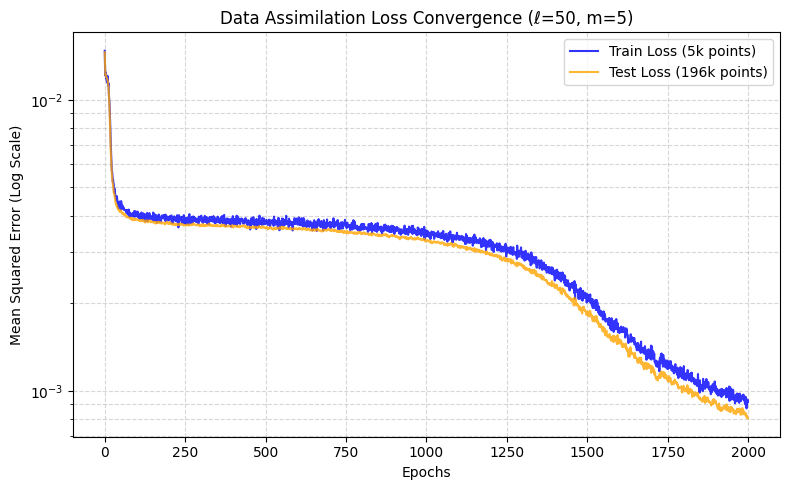

Generating Data Assimilation Heatmap Grid...


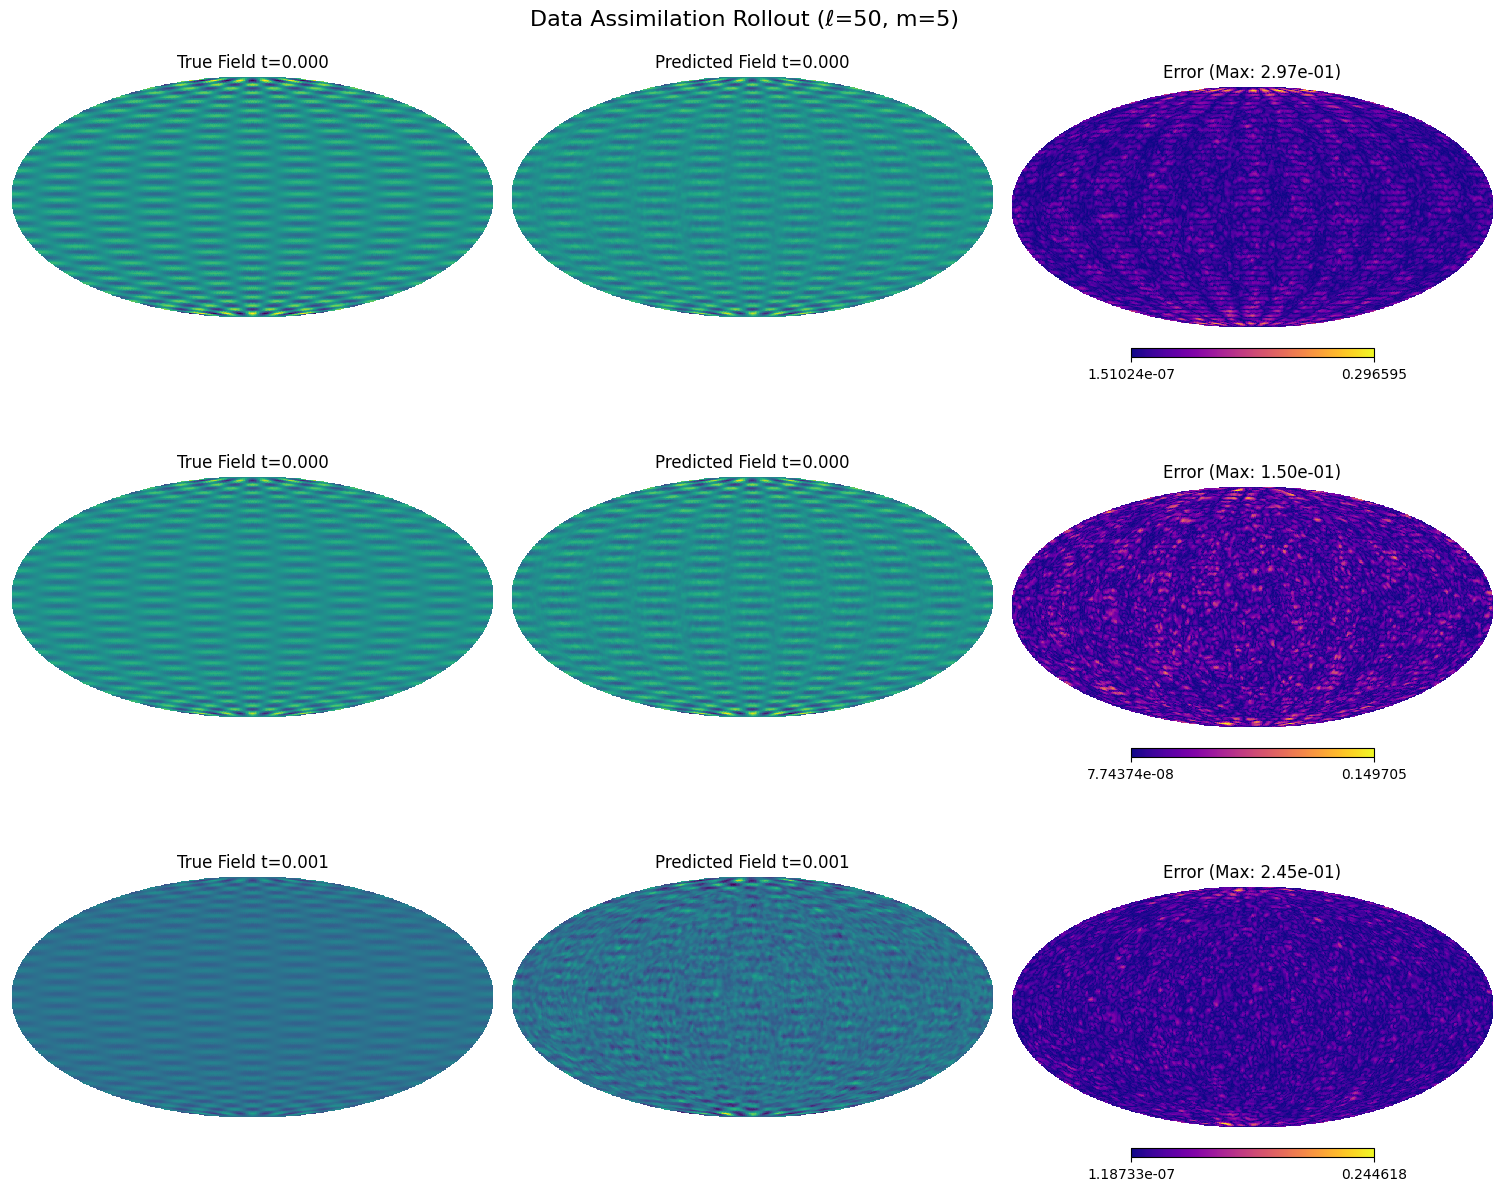

In [11]:
#Individual Testing with loss curves

l_target, m_target = 50, 5
NSIDE = 128
times = get_eval_times(l_target)

print(f"\nInitializing HEALPix Dataset for l={l_target} (NSIDE={NSIDE})...")
dataset = HealpixHeatDataset(l_target, m_target, NSIDE, times)

# Build the graph (This creates a 196k x 196k sparse matrix)
print("Building Graph Laplacian (this takes a few seconds)...")
laplacian = build_healpix_laplacian(NSIDE)

# Initialize the new architectures
branch = HealpixBranchNet(NSIDE, laplacian)
trunk = SirenTrunkNet(in_features=4, hidden_features=128, out_features=64, omega_0=50.0)

model = DeepONet(branch, trunk)

# Using a slightly lower learning rate because SIRENs + GCNs can be aggressive
optimizer = optim.Adam(model.parameters(), lr=5e-4)
loss_fn = nn.MSELoss()

# Train and get the loss arrays
train_losses, test_losses = train_and_track_da(dataset, model, optimizer, loss_fn, num_epochs=2000)

# Plot 1 & 2: The Loss Curves
plot_loss_curves(train_losses, test_losses, l_target, m_target, title_prefix="Data Assimilation")

# Plot 3: The Heat-maps
print("Generating Data Assimilation Heatmap Grid...")
plot_da_heatmap_grid(dataset, model, times_to_plot=times)


Initializing HEALPix Dataset for l=50 (NSIDE=128)...


/tmp/ipykernel_731/61072990.py:264: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Ylm = sph_harm(self.m, self.l, self.phi_hp, self.theta_hp)


Building Graph Laplacian (this takes a few seconds)...
Starting HEALPix Training...
Epoch 0, Loss: 0.04113635083194822
Epoch 20, Loss: 0.01912291394546628
Epoch 40, Loss: 0.013202238013036549
Epoch 60, Loss: 0.012388803996145725
Epoch 80, Loss: 0.012465879728551954
Epoch 100, Loss: 0.012248269806150347
Epoch 120, Loss: 0.012136398174334317
Epoch 140, Loss: 0.01231354259653017
Epoch 160, Loss: 0.011708370584528893
Epoch 180, Loss: 0.011598145414609462
Epoch 200, Loss: 0.011684784200042486
Epoch 220, Loss: 0.011605990235693753
Epoch 240, Loss: 0.011026211024727672
Epoch 260, Loss: 0.011757859436329454
Epoch 280, Loss: 0.01169905555434525
Epoch 300, Loss: 0.01119964086683467
Epoch 320, Loss: 0.011390356870833784
Epoch 340, Loss: 0.011451464495621622
Epoch 360, Loss: 0.011222277651540935
Epoch 380, Loss: 0.011236658319830894
Epoch 400, Loss: 0.01166104560252279
Epoch 420, Loss: 0.011159938876517117
Epoch 440, Loss: 0.01146997750038281
Epoch 460, Loss: 0.01156519929645583
Epoch 480, Loss: 0

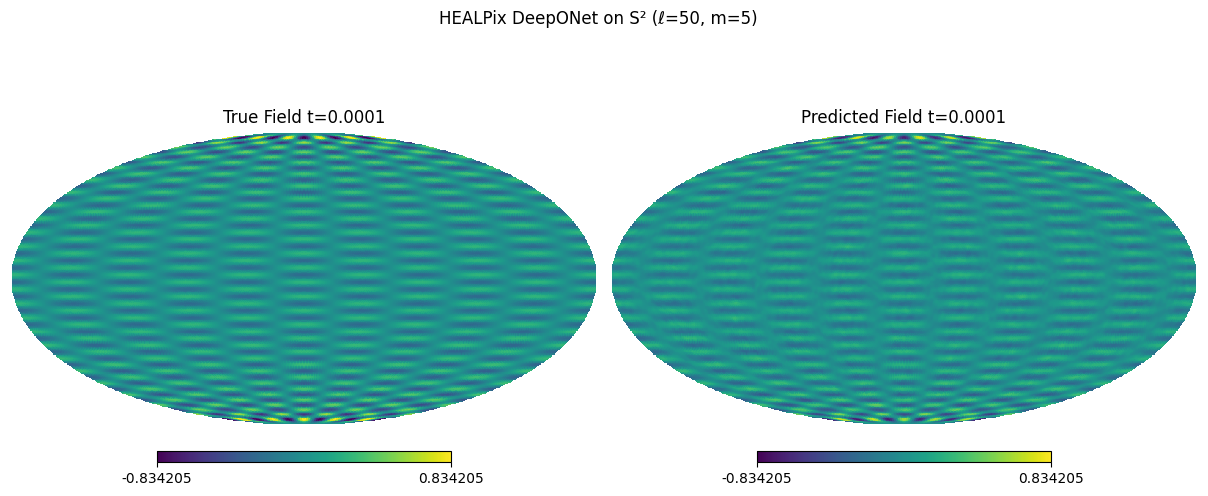

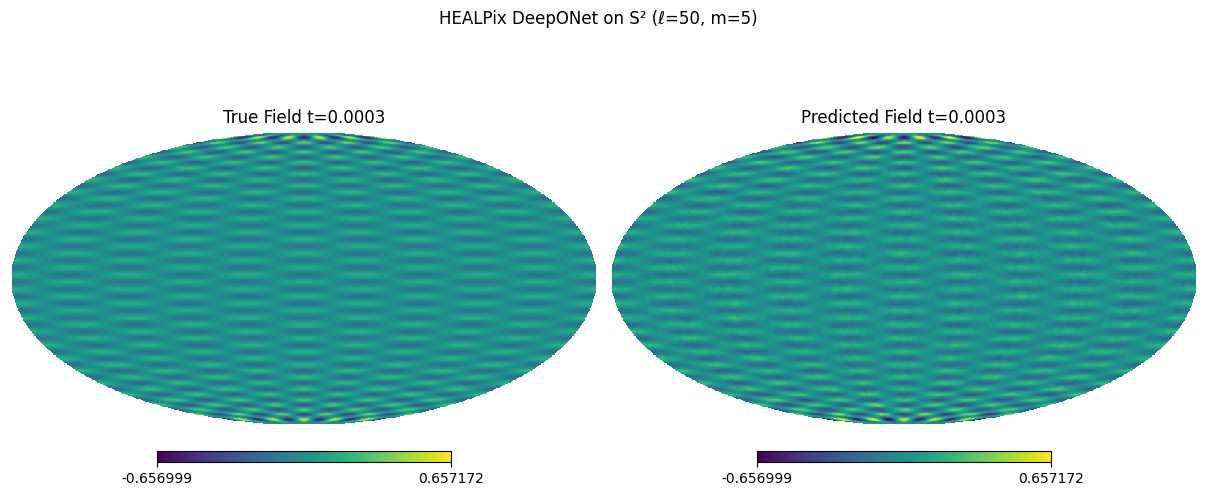

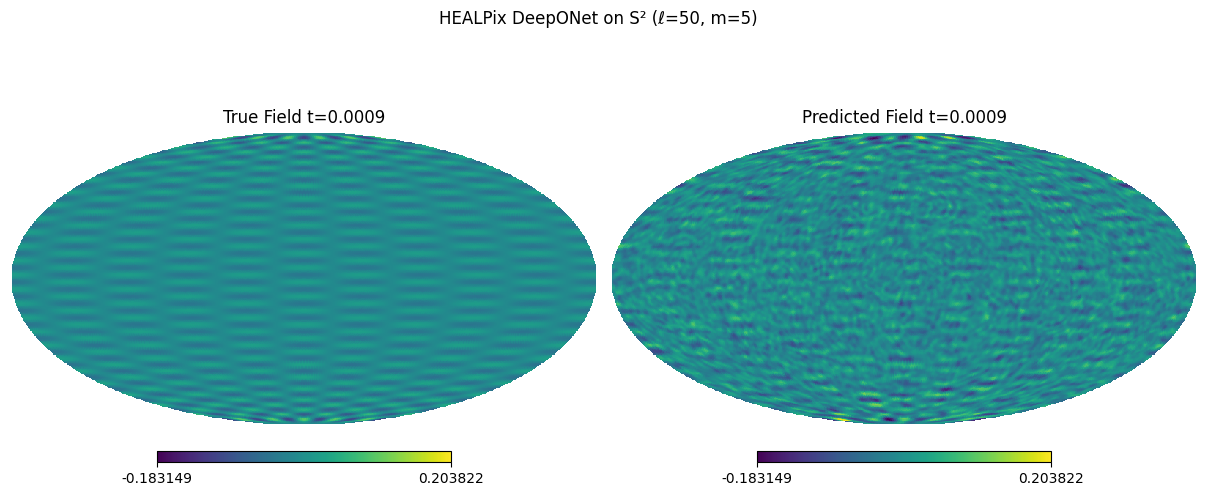

In [8]:
# individual testing however no loss curves

l_target, m_target = 50, 5
NSIDE = 128
times = get_eval_times(l_target)

print(f"\nInitializing HEALPix Dataset for l={l_target} (NSIDE={NSIDE})...")
dataset = HealpixHeatDataset(l_target, m_target, NSIDE, times)

# Build the graph (This creates a 196k x 196k sparse matrix)
print("Building Graph Laplacian (this takes a few seconds)...")
laplacian = build_healpix_laplacian(NSIDE)

# Initialize the new architectures
branch = HealpixBranchNet(NSIDE, laplacian)
trunk = SirenTrunkNet(in_features=4, hidden_features=128, out_features=64, omega_0=50.0)

model = DeepONet(branch, trunk)

# Using a slightly lower learning rate because SIRENs + GCNs can be aggressive
optimizer = optim.Adam(model.parameters(), lr=5e-4)
loss_fn = nn.MSELoss()

# Train! Sampling 5000 random pixels per time step to save GPU memory
print("Starting HEALPix Training...")
train_model_healpix(dataset, model, optimizer, loss_fn, num_epochs=2000, n_samples=5000)

# Visualize the final result
print("Generating Mollweide projections...")
for t in times:
    plot_healpix_comparison(dataset, model, t)

TIME EVOLUTION

In [12]:
# # During your initialization phase, simply change the in_features argument:
# trunk = SirenTrunkNet(in_features=3, hidden_features=128, out_features=64, omega_0=30.0)

## 6. Training Functions
Defines training loops for different experiments (standard grid, data assimilation, fibonacci sphere).